In [1]:
import os
import glob
import inspect
import numpy as np
import matplotlib.pyplot as plt

import healpy as hp
from astropy.io import fits

import limTOD
from limTOD import generate_LSTs_deg, generate_TOD_sky
from limTOD import GDSM_sky_model
from limTOD import HPW_mapmaking

print("limTOD imported from:")
print(limTOD.__file__)

print("\nHPW_mapmaking from:")
print(inspect.getfile(HPW_mapmaking))

print("\nHPW_mapmaking.__call__ signature:")
print(inspect.signature(HPW_mapmaking.__call__))

limTOD imported from:
/Users/zzhang/Workspace/RadioCosmology/limTOD/limTOD/__init__.py

HPW_mapmaking from:
/Users/zzhang/Workspace/RadioCosmology/limTOD/limTOD/HPW_filter.py

HPW_mapmaking.__call__ signature:
(self, *, TOD_group, dtime, cutoff_freq_group=None, gain_group=None, known_injection_group=None, Tsky_prior_mean=None, Tsky_prior_inv_cov_diag=None, Tsys_other_prior_mean_group=None, Tsys_other_prior_inv_cov_group=None, noise_variance=None, regularization=1e-12, return_full_cov=False, filter_order=4, preserve_dc=False, use_high_pass=False)


In [2]:
# ============================================================
# USER SETTINGS
# ============================================================

FREQ_MHZ = 70.0

# Keep simulation and mapmaking at same low resolution first
NSIDE = 4

# Beam folder from your copied/symlinked data
#BEAM_DIR = os.path.expanduser("~/LimTOD/rhino-TODsim/data/HornDry")
# BEAM_DIR = os.path.expanduser("~/LimTOD/rhino-TODsim/data/DipoleDry")
BEAM_DIR = os.path.expanduser("/Users/zzhang/Dataspace/MERS/HornWet")


# RHINO site
ANT_LAT = 53.2421
ANT_LON = -2.3067
ANT_H   = 0.0

START_TIME = "2026-04-01 00:00:00"

# 4 hour simulation
N_HOURS = 4 #24
DT = 30.0
N_TIME = int(N_HOURS * 3600 / DT)

time_list = np.arange(N_TIME) * DT
time_hours = time_list / 3600.0

# Zenith pointing
azimuth_deg_list = np.zeros(N_TIME)
elevation_deg_list = np.ones(N_TIME) * 90.0

# Antenna rotation: 360 degrees per hour
selfrot_deg_list = (360.0 * time_hours) % 360.0

# Mapmaker settings
THRESHOLD = 0.001
# TRUNC_FRAC = THRESHOLD
TRUNC_FRAC = 0.00001

# THRESHOLD: threshold used by the mapmaker to select sky pixels.
# TRUNC_FRAC: threshold used to truncate the beam itself; can be used in both TOD simulation and mapmaking.



REGULARIZATION = 1e-6

# No 1/f noise in this controlled test
USE_HIGH_PASS = False
CUTOFF_FREQ = 1e-8
FILTER_ORDER = 4

# Mild prior comparison
MILD_PRIOR_SIGMA_FACTOR = 0.3

print(f"N_TIME = {N_TIME}")
print(f"Samples per rotation = {3600 / DT:.0f}")
print(f"Total rotations = {N_HOURS}")

N_TIME = 480
Samples per rotation = 120
Total rotations = 4


In [3]:
import re

def extract_frequency_from_filename(path):
    """
    Extract a frequency like 70.0 from filenames such as:
    DipoleDry70.0.fits, DipoleDry_70MHz.fits, HornWet55.0.fits, etc.
    """
    name = os.path.basename(path)

    patterns = [
        r"(\d+(?:\.\d+)?)\s*MHz",
        r"(\d+(?:\.\d+)?)\.fits",
        r"(\d+(?:\.\d+)?)"
    ]

    for pat in patterns:
        matches = re.findall(pat, name, flags=re.IGNORECASE)
        if matches:
            nums = [float(m) for m in matches]
            
            return nums[-1]

    return None


def find_closest_beam_file(beam_dir, target_freq_mhz):
    files = sorted(glob.glob(os.path.join(beam_dir, "*.fits")))

    if len(files) == 0:
        raise FileNotFoundError(f"No FITS files found in: {beam_dir}")

    candidates = []
    for f in files:
        freq = extract_frequency_from_filename(f)
        if freq is not None:
            candidates.append((abs(freq - target_freq_mhz), freq, f))

    if len(candidates) == 0:
        raise RuntimeError(
            f"Could not infer frequencies from FITS filenames in {beam_dir}."
        )

    candidates.sort(key=lambda x: x[0])
    diff, freq, path = candidates[0]

    print("Selected beam file:")
    print(path)
    print(f"Beam file frequency inferred from name: {freq:.3f} MHz")
    print(f"Requested frequency: {target_freq_mhz:.3f} MHz")
    print(f"Difference: {diff:.3f} MHz")

    return path, freq


beam_file, beam_file_freq = find_closest_beam_file(BEAM_DIR, FREQ_MHZ)

Selected beam file:
/Users/zzhang/Dataspace/MERS/HornWet/HornWet70.0.fits
Beam file frequency inferred from name: 70.000 MHz
Requested frequency: 70.000 MHz
Difference: 0.000 MHz


In [4]:
def infer_nside_from_size(npix):
    nside = hp.npix2nside(npix)
    if hp.nside2npix(nside) != npix:
        raise ValueError(f"Array length {npix} is not a valid HEALPix NPIX.")
    return nside


def load_healpix_beam_from_fits(path, target_nside=None, field_index=0, assume_ring=True):
    """
    Robustly load a HEALPix beam map from a FITS file.

    Handles:
    - Image HDUs containing a 1D HEALPix map
    - Binary table HDUs with scalar rows
    - Binary table HDUs with vector columns

    Returns:
    - beam map at target_nside if given
    """

    print(f"Loading beam FITS:\n{path}")

    with fits.open(path) as hdul:
        print("\nFITS structure:")
        hdul.info()

        beam = None

        # image HDUs first
        for hdu in hdul:
            data = hdu.data
            if data is None:
                continue

            arr = np.asarray(data)

            if arr.ndim == 1:
                try:
                    infer_nside_from_size(arr.size)
                    beam = arr.astype(float)
                    print("\nLoaded beam from 1D image HDU.")
                    break
                except Exception:
                    pass

            if arr.ndim > 1:
                flat = arr.ravel()
                try:
                    infer_nside_from_size(flat.size)
                    beam = flat.astype(float)
                    print("\nLoaded beam from flattened image HDU.")
                    break
                except Exception:
                    pass

        # binary table HDUs
        if beam is None:
            for hdu in hdul:
                data = hdu.data
                if data is None:
                    continue

                if not hasattr(data, "columns"):
                    continue

                colnames = data.columns.names
                print("\nTrying table columns:", colnames)

                # Prefer requested field index, but search all columns if needed
                ordered_cols = [colnames[field_index]] + [
                    c for c in colnames if c != colnames[field_index]
                ]

                for col in ordered_cols:
                    arr = np.asarray(data[col])

                    # Case 1: one scalar per pixel
                    if arr.ndim == 1:
                        try:
                            infer_nside_from_size(arr.size)
                            beam = arr.astype(float)
                            print(f"Loaded scalar HEALPix column: {col}")
                            break
                        except Exception:
                            pass

                    # Case 2: rows contain vector chunks
                    flat = arr.ravel()
                    try:
                        infer_nside_from_size(flat.size)
                        beam = flat.astype(float)
                        print(f"Loaded vector HEALPix column: {col}")
                        break
                    except Exception:
                        pass

                if beam is not None:
                    break

    if beam is None:
        raise RuntimeError(f"Could not find a valid HEALPix beam map in {path}")

    beam = np.asarray(beam, dtype=float)
    beam = np.nan_to_num(beam, nan=0.0, posinf=0.0, neginf=0.0)

    input_nside = infer_nside_from_size(beam.size)
    print(f"\nInput beam NSIDE = {input_nside}")
    print(f"Input beam min/max = {beam.min():.4e}, {beam.max():.4e}")

    # Use absolute if beam has tiny negative numerical values
    if beam.min() < 0:
        print("Warning: beam has negative values. Taking absolute value for power response.")
        beam = np.abs(beam)

    # Degrade to target NSIDE
    if target_nside is not None and target_nside != input_nside:
        beam = hp.ud_grade(beam, nside_out=target_nside, power=0)
        beam = np.nan_to_num(beam, nan=0.0, posinf=0.0, neginf=0.0)
        print(f"Degraded beam to NSIDE = {target_nside}")

    # Normalize peak to 1.
    # This keeps thresholding meaningful and makes beam convention stable.
    peak = np.max(np.abs(beam))
    if peak <= 0:
        raise ValueError("Beam peak is zero; cannot normalize.")

    beam = beam / peak

    print(f"Final beam NSIDE = {hp.npix2nside(len(beam))}")
    print(f"Final beam min/max = {beam.min():.4e}, {beam.max():.4e}")
    print(f"Final beam mean = {beam.mean():.4e}")

    return beam


beam_map = load_healpix_beam_from_fits(
    beam_file,
    target_nside=NSIDE,
    field_index=0
)

Loading beam FITS:
/Users/zzhang/Dataspace/MERS/HornWet/HornWet70.0.fits

FITS structure:
Filename: /Users/zzhang/Dataspace/MERS/HornWet/HornWet70.0.fits
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  PRIMARY       1 PrimaryHDU       4   ()      
  1  xtension      1 BinTableHDU     18   3072R x 1C   [1024D]   

Loaded beam from 1D image HDU.

Input beam NSIDE = 16
Input beam min/max = 1.2406e-10, 8.5769e-06
Degraded beam to NSIDE = 4
Final beam NSIDE = 4
Final beam min/max = 8.7214e-05, 1.0000e+00
Final beam mean = 5.0294e-02


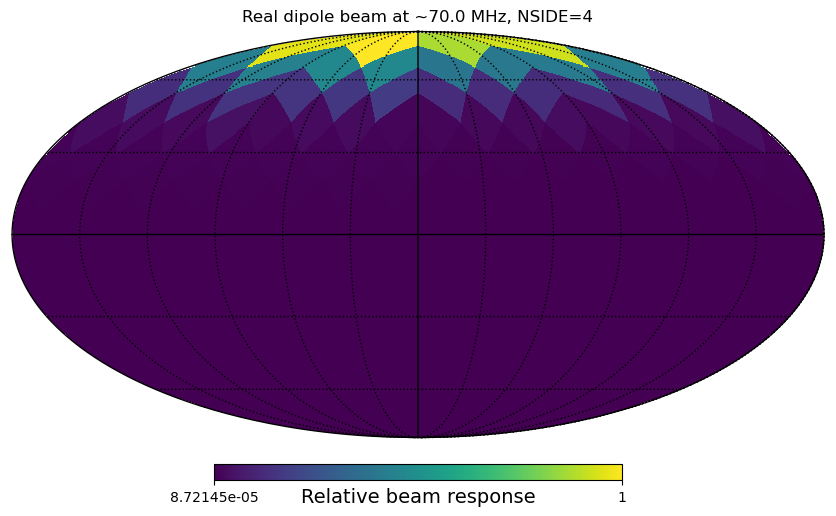

Beam diagnostics:
NSIDE: 4
NPIX: 192
min: 8.721449812104361e-05
max: 1.0
mean: 0.050293574671747436
nonzero pixels: 192


In [5]:
hp.mollview(
    beam_map,
    title=f"Real dipole beam at ~{beam_file_freq:.1f} MHz, NSIDE={NSIDE}",
    unit="Relative beam response",
    cmap="viridis"
)
hp.graticule()
plt.show()

print("Beam diagnostics:")
print("NSIDE:", hp.npix2nside(len(beam_map)))
print("NPIX:", len(beam_map))
print("min:", np.min(beam_map))
print("max:", np.max(beam_map))
print("mean:", np.mean(beam_map))
print("nonzero pixels:", np.count_nonzero(beam_map))

Sky diagnostics:
NSIDE: 4
NPIX: 192
min: 1234.27685546875 K
max: 14255.6513671875 K
mean: 2757.633856455485 K


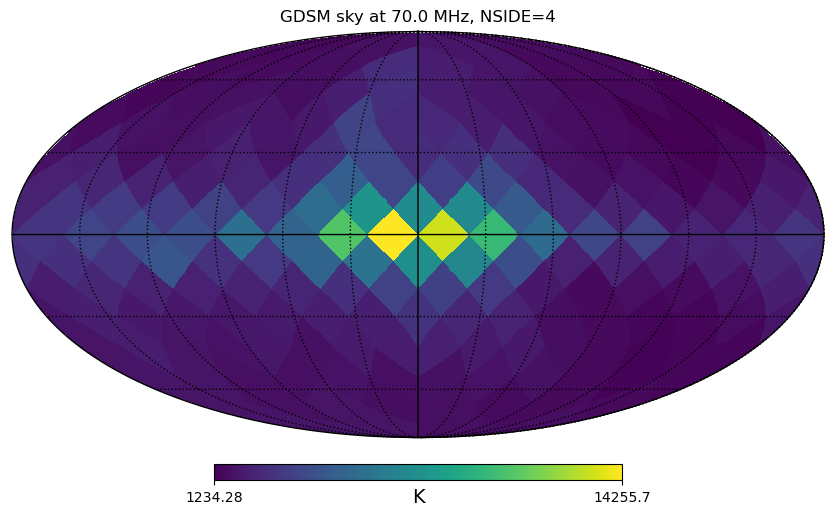

In [6]:
sky_map = GDSM_sky_model(freq=FREQ_MHZ, nside=NSIDE)
sky_map = np.asarray(sky_map, dtype=float)
sky_map = np.nan_to_num(sky_map, nan=0.0, posinf=0.0, neginf=0.0)

print("Sky diagnostics:")
print("NSIDE:", hp.npix2nside(len(sky_map)))
print("NPIX:", len(sky_map))
print("min:", np.min(sky_map), "K")
print("max:", np.max(sky_map), "K")
print("mean:", np.mean(sky_map), "K")

hp.mollview(
    sky_map,
    title=f"GDSM sky at {FREQ_MHZ:.1f} MHz, NSIDE={NSIDE}",
    unit="K",
    cmap="viridis"
)
hp.graticule()
plt.show()

In [7]:
print("generate_LSTs_deg signature:")
print(inspect.signature(generate_LSTs_deg))

generate_LSTs_deg signature:
(ant_latitude_deg, ant_longitude_deg, ant_height_m, time_list, start_time_utc='2019-04-23 20:41:56.397')


In [8]:
LST_deg_list = generate_LSTs_deg(
    ant_latitude_deg=ANT_LAT,
    ant_longitude_deg=ANT_LON,
    ant_height_m=ANT_H,
    time_list=time_list,
    start_time_utc=START_TIME,
)

LST_deg_list = np.asarray(LST_deg_list)

print("LST diagnostics:")
print("Shape:", LST_deg_list.shape)
print("First five LSTs:", LST_deg_list[:5])
print("Min/max:", np.min(LST_deg_list), np.max(LST_deg_list))

LST diagnostics:
Shape: (480,)
First five LSTs: [187.06419749 187.18953972 187.31488194 187.44022416 187.56556639]
Min/max: 187.06419749106277 247.10312285524918


In [9]:
print("generate_TOD_sky signature:")
print(inspect.signature(generate_TOD_sky))

generate_TOD_sky signature:
(beam_map, sky_map, LST_deg_list, lat_deg, azimuth_deg_list, elevation_deg_list, selfrot_deg_list, nside_hires=None, normalize_beam=False, horizontal_mask=None, truncate_frac_thres=1e-10)


In [10]:
TOD = generate_TOD_sky(
    beam_map=beam_map,
    sky_map=sky_map,
    LST_deg_list=LST_deg_list,
    lat_deg=ANT_LAT,
    azimuth_deg_list=azimuth_deg_list,
    elevation_deg_list=elevation_deg_list,
    selfrot_deg_list=selfrot_deg_list,
    normalize_beam=False,
    truncate_frac_thres=TRUNC_FRAC,
)

TOD = np.asarray(TOD, dtype=float)

print("TOD diagnostics:")
print("shape:", TOD.shape)
print("min:", np.min(TOD), "K")
print("max:", np.max(TOD), "K")
print("mean:", np.mean(TOD), "K")
print("std:", np.std(TOD), "K")

100%|██████████| 480/480 [00:03<00:00, 143.40it/s]

TOD diagnostics:
shape: (480,)
min: 15600.972310666064 K
max: 16600.944038562142 K
mean: 15904.952022857482 K
std: 233.19733109087505 K


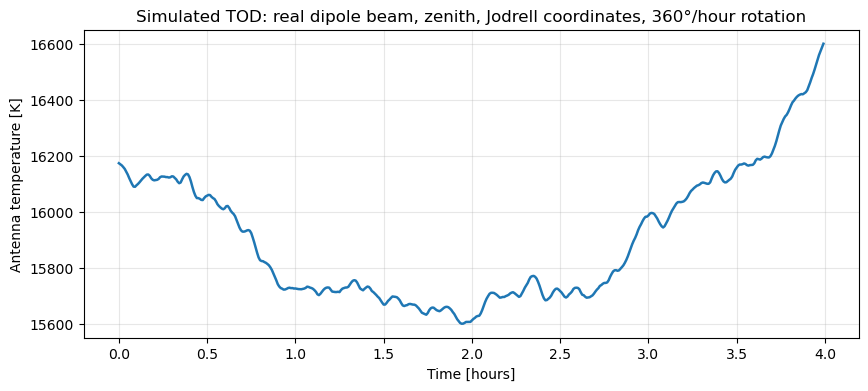

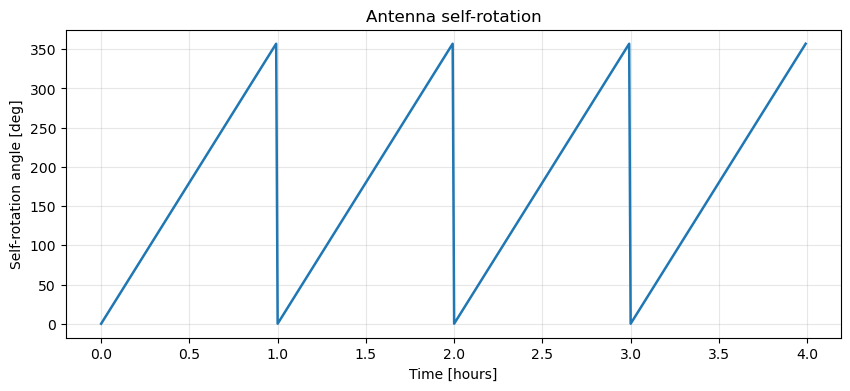

In [11]:
plt.figure(figsize=(10, 4))
plt.plot(time_hours, TOD, lw=1.8)
plt.xlabel("Time [hours]")
plt.ylabel("Antenna temperature [K]")
plt.title("Simulated TOD: real dipole beam, zenith, Jodrell coordinates, 360°/hour rotation")
plt.grid(alpha=0.3)
plt.show()

plt.figure(figsize=(10, 4))
plt.plot(time_hours, selfrot_deg_list, lw=1.8)
plt.xlabel("Time [hours]")
plt.ylabel("Self-rotation angle [deg]")
plt.title("Antenna self-rotation")
plt.grid(alpha=0.3)
plt.show()

In [12]:
import inspect
from limTOD import HPW_mapmaking

print("HPW_mapmaking init signature:")
print(inspect.signature(HPW_mapmaking))

print("\nHPW_mapmaking.__call__ signature:")
print(inspect.signature(HPW_mapmaking.__call__))

HPW_mapmaking init signature:
(*, beam_map, LST_deg_list_group, lat_deg, azimuth_deg_list_group, elevation_deg_list_group, selfrot_deg_list_group=None, threshold=0.01, Tsys_others_operator_group=None, nside_hires=None, nside_target=None, beam_truncate_frac_thres=None)

HPW_mapmaking.__call__ signature:
(self, *, TOD_group, dtime, cutoff_freq_group=None, gain_group=None, known_injection_group=None, Tsky_prior_mean=None, Tsky_prior_inv_cov_diag=None, Tsys_other_prior_mean_group=None, Tsys_other_prior_inv_cov_group=None, noise_variance=None, regularization=1e-12, return_full_cov=False, filter_order=4, preserve_dc=False, use_high_pass=False)


In [13]:
mapper = HPW_mapmaking(
    beam_map=beam_map,
    LST_deg_list_group=LST_deg_list,
    lat_deg=ANT_LAT,
    azimuth_deg_list_group=azimuth_deg_list,
    elevation_deg_list_group=elevation_deg_list,
    selfrot_deg_list_group=selfrot_deg_list,
    threshold=THRESHOLD,
    beam_truncate_frac_thres=TRUNC_FRAC,
    nside_target=NSIDE,
)

print("Mapper created successfully.")


Step 1: Generating the stacked abs(beam) map ... 



100%|██████████| 480/480 [00:03<00:00, 147.12it/s]



Step 2: Selecting pixels above threshold sensitivity ... 

Number of data points: 480
Number of selected pixels: 192


100%|██████████| 480/480 [00:03<00:00, 145.27it/s]

Mapper created successfully.


In [14]:
pix = np.asarray(mapper.pixel_indices, dtype=int)

print("Using mapper pixel attribute: pixel_indices")
print("Number of selected pixels:", len(pix))
print("Number of TOD samples:", len(TOD))
print("First few pixel indices:", pix[:10])
print("Pixel index min/max:", pix.min(), pix.max())

Using mapper pixel attribute: pixel_indices
Number of selected pixels: 192
Number of TOD samples: 480
First few pixel indices: [0 1 2 3 4 5 6 7 8 9]
Pixel index min/max: 0 191


In [15]:
truth_patch = sky_map[pix]

print("Truth patch shape:", truth_patch.shape)
print("Recovered patch shape will be compared after mapmaking.")

Truth patch shape: (192,)
Recovered patch shape will be compared after mapmaking.


In [16]:
sky_est_patch, sky_unc_patch = mapper(
    TOD_group=TOD,
    dtime=DT,
    cutoff_freq_group=None,
    gain_group=1.0,
    Tsky_prior_mean=None,
    Tsky_prior_inv_cov_diag=None,
    noise_variance=None,
    regularization=REGULARIZATION,
    filter_order=FILTER_ORDER,
    preserve_dc=False,
    use_high_pass=False,
)

sky_est_patch = np.asarray(sky_est_patch, dtype=float)
sky_unc_patch = np.asarray(sky_unc_patch, dtype=float)

print("Recovered patch shape:", sky_est_patch.shape)
print("Uncertainty patch shape:", sky_unc_patch.shape)
print("Truth patch shape:", truth_patch.shape)

Recovered patch shape: (192,)
Uncertainty patch shape: (192,)
Truth patch shape: (192,)


In [17]:
residual_patch = sky_est_patch - truth_patch

rmse = np.sqrt(np.mean(residual_patch**2))
bias = np.mean(residual_patch)

if np.std(sky_est_patch) > 0 and np.std(truth_patch) > 0:
    corr = np.corrcoef(sky_est_patch, truth_patch)[0, 1]
else:
    corr = np.nan

print("No-prior mapmaking diagnostics")
print("--------------------------------")
print(f"Selected pixels : {len(pix)}")
print(f"TOD samples     : {len(TOD)}")
print(f"RMSE [K]        : {rmse:.4f}")
print(f"Bias [K]        : {bias:.4f}")
print(f"Correlation     : {corr:.4f}")

No-prior mapmaking diagnostics
--------------------------------
Selected pixels : 192
TOD samples     : 480
RMSE [K]        : 0.0343
Bias [K]        : 0.0008
Correlation     : 1.0000


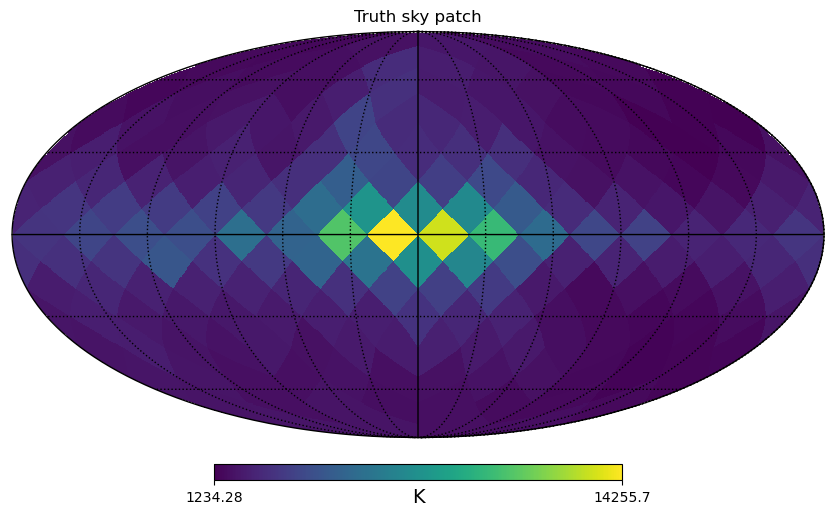

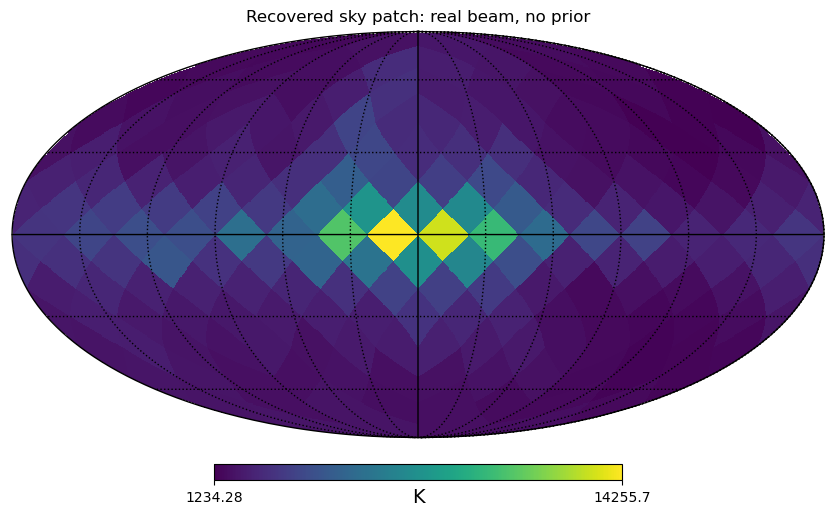

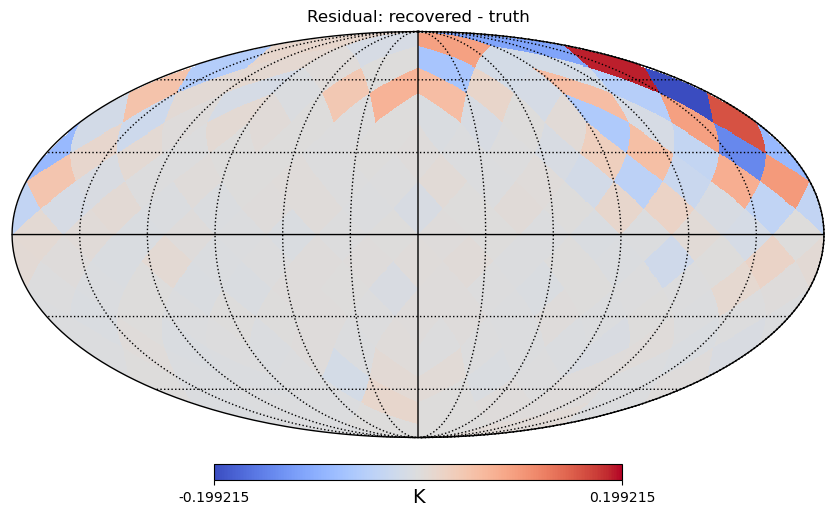

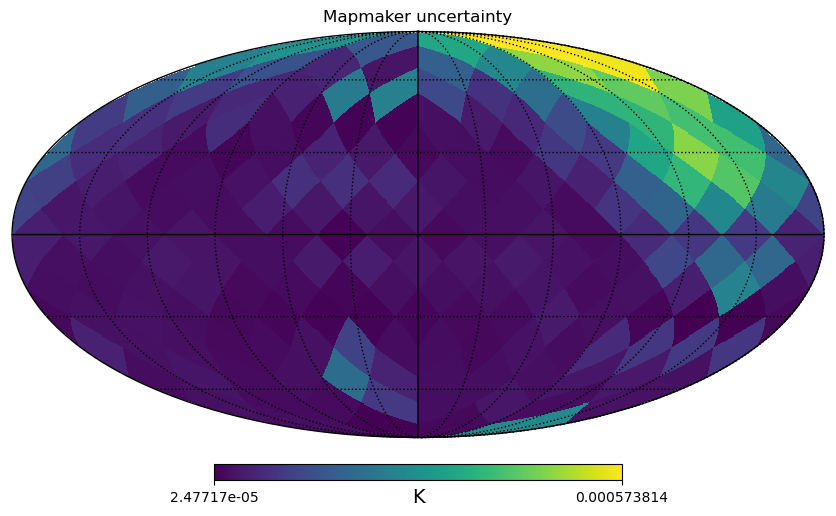

In [18]:
def patch_to_full_map(pix, values, nside, unseen=hp.UNSEEN):
    full_map = np.full(hp.nside2npix(nside), unseen, dtype=float)
    full_map[pix] = values
    return full_map

truth_full = patch_to_full_map(pix, truth_patch, NSIDE)
recovered_full = patch_to_full_map(pix, sky_est_patch, NSIDE)
residual_full = patch_to_full_map(pix, residual_patch, NSIDE)
unc_full = patch_to_full_map(pix, sky_unc_patch, NSIDE)

vmin = np.nanmin(truth_patch)
vmax = np.nanmax(truth_patch)

hp.mollview(
    truth_full,
    title="Truth sky patch",
    unit="K",
    min=vmin,
    max=vmax,
    cmap="viridis",
)
hp.graticule()
plt.show()

hp.mollview(
    recovered_full,
    title="Recovered sky patch: real beam, no prior",
    unit="K",
    min=vmin,
    max=vmax,
    cmap="viridis",
)
hp.graticule()
plt.show()

res_lim = np.nanmax(np.abs(residual_patch))

hp.mollview(
    residual_full,
    title="Residual: recovered - truth",
    unit="K",
    min=-res_lim,
    max=res_lim,
    cmap="coolwarm",
)
hp.graticule()
plt.show()

hp.mollview(
    unc_full,
    title="Mapmaker uncertainty",
    unit="K",
    cmap="viridis",
)
hp.graticule()
plt.show()

In [19]:
print("truth_patch shape:", truth_patch.shape)
print("sky_est_patch shape:", sky_est_patch.shape)

diff = sky_est_patch - truth_patch

print("Max abs difference:", np.max(np.abs(diff)))
print("Mean abs difference:", np.mean(np.abs(diff)))
print("RMSE:", np.sqrt(np.mean(diff**2)))
print("Are they exactly equal?", np.array_equal(sky_est_patch, truth_patch))
print("Are they close?", np.allclose(sky_est_patch, truth_patch))

truth_patch shape: (192,)
sky_est_patch shape: (192,)
Max abs difference: 0.19921516251815774
Mean abs difference: 0.01497010197068486
RMSE: 0.03425608854256795
Are they exactly equal? False
Are they close? False
